# **1. 손 글씨 숫자 데이터셋**

손글씨 숫자 데이터셋은 0부터 9까지의 숫자를 손글씨로 쓴 흑백 이미지로 구성되어 있으며, 각 이미지는 8x8 픽셀 크기의 64차원 벡터로 표현된다. 각 픽셀 값은 0(흰색)에서 16(검은색)까지의 명암값을 가진다. 이 데이터는 총 1797개의 샘플로 이루어져 있으며, 각 샘플에는 숫자 클래스(0~9)가 레이블로 붙어 있다. 주로 분류 알고리즘을 학습시키거나 데이터 시각화, 차원 축소 기법 등을 실험하는 데 사용된다.
- 데이터 shape: (1797 x 64)

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader # mini-batch로 학습시킬 때 필요한 모듈

In [109]:
digits = load_digits()

X_data = digits['data']
y_data = digits['target']

print(X_data.shape)
print(y_data.shape)

(1797, 64)
(1797,)


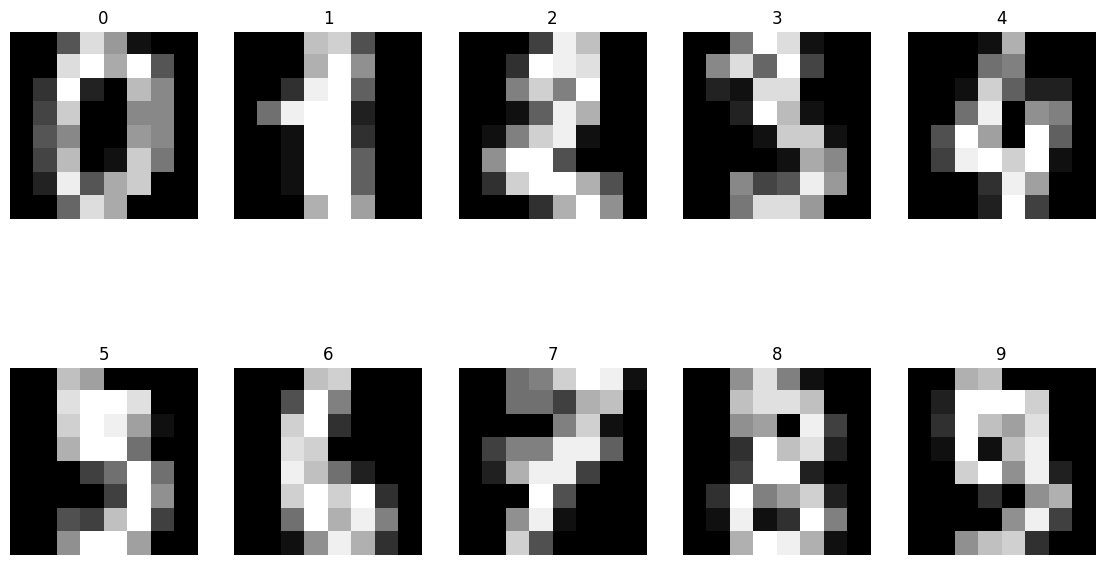

In [110]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 8))

for i, ax in enumerate(axes.flatten()): # axes.flatten(): 2 x 5 -> 1 x 10
    ax.imshow(X_data[i].reshape((8, 8)), cmap='gray')
    ax.set_title(y_data[i])
    ax.axis('off')

In [111]:
X_data = torch.FloatTensor(X_data)
y_data = torch.LongTensor(y_data) # 분류문제이기 때문에 target값은 LongTensor

print(X_data.shape)
print(y_data.shape)

torch.Size([1797, 64])
torch.Size([1797])


In [112]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=2026)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

torch.Size([1437, 64])
torch.Size([360, 64])
torch.Size([1437])
torch.Size([360])


# **2. 데이터 로더**

데이터로더(Data Loader)는 **데이터셋을 효율적으로 관리하고, 모델 학습 과정에서 데이터를 쉽게 가져올 수 있도록 도와주는 도구**이다. 일반적으로 데이터셋을 배치(batch) 단위로 나누어 모델에 제공하며, 데이터의 크기가 클 경우에도 메모리 효율적으로 처리할 수 있도록 설계되어 있다. **데이터 증강, 셔플링, 병렬 처리와 같은 기능을 지원하여 학습 성능을 향상시키고, 모델 학습과 평가 시 일관된 데이터 제공 방식을 유지**한다. 딥러닝 프레임워크에서는 PyTorch의 DataLoader나 TensorFlow의 tf.data 같은 도구를 통해 쉽게 사용할 수 있다.

### ※ 데이터 로더의 주요 역할
1. 배치 처리: 데이터를 지정된 크기의 배치로 나누어 모델에 제공.
2. 셔플링: 데이터 순서를 무작위로 섞어 과적합 방지.
3. 병렬 처리: num_workers 옵션을 통해 데이터를 병렬로 로드하여 속도 향상.
4. 반복 처리: 학습 epoch 동안 데이터를 자동으로 반복해서 제공.

In [113]:
list(zip(X_train, y_train))

[(tensor([ 0.,  0.,  5., 11., 16., 16.,  5.,  0.,  0.,  3., 15., 11., 10., 16.,
           4.,  0.,  0.,  0.,  4.,  0., 10., 14.,  0.,  0.,  0.,  0.,  7., 15.,
          16., 16., 12.,  0.,  0.,  0.,  9., 16., 14.,  4.,  1.,  0.,  0.,  0.,
           1., 14.,  7.,  0.,  0.,  0.,  0.,  0.,  4., 16.,  4.,  0.,  0.,  0.,
           0.,  0.,  8., 16.,  0.,  0.,  0.,  0.]),
  tensor(7)),
 (tensor([ 0.,  3., 13., 16., 13.,  0.,  0.,  0.,  0.,  9., 13.,  8., 16.,  5.,
           1.,  0.,  0.,  0.,  8., 14., 16., 16.,  5.,  0.,  0.,  0.,  8., 16.,
          15.,  2.,  0.,  0.,  0.,  0.,  2., 16.,  7.,  0.,  0.,  0.,  0.,  0.,
           7., 16.,  4.,  0.,  0.,  0.,  0.,  0., 15.,  9.,  0.,  0.,  0.,  0.,
           0.,  2., 15.,  3.,  0.,  0.,  0.,  0.]),
  tensor(7)),
 (tensor([ 0.,  0.,  2., 13.,  6.,  0.,  0.,  0.,  0.,  0.,  4., 16., 15.,  5.,
           0.,  0.,  0.,  0.,  1., 15., 12., 15.,  0.,  0.,  0.,  0.,  0., 10.,
          16., 16.,  1.,  0.,  0.,  0.,  0.,  0.,  2., 16.,  2.,  0.

In [114]:
loader = DataLoader(
    dataset=list(zip(X_train, y_train)),
    batch_size=64, # 1437 / 64 = 22.45... >>> 22번의 기울기 업데이트
    shuffle = True,
    drop_last=False # 1437 % 64 = 29 >>> 0.45...로 남은 데이터를 지우지 않고 모아서 1회로 기울기 업데이트할 수 있게 해줌
)

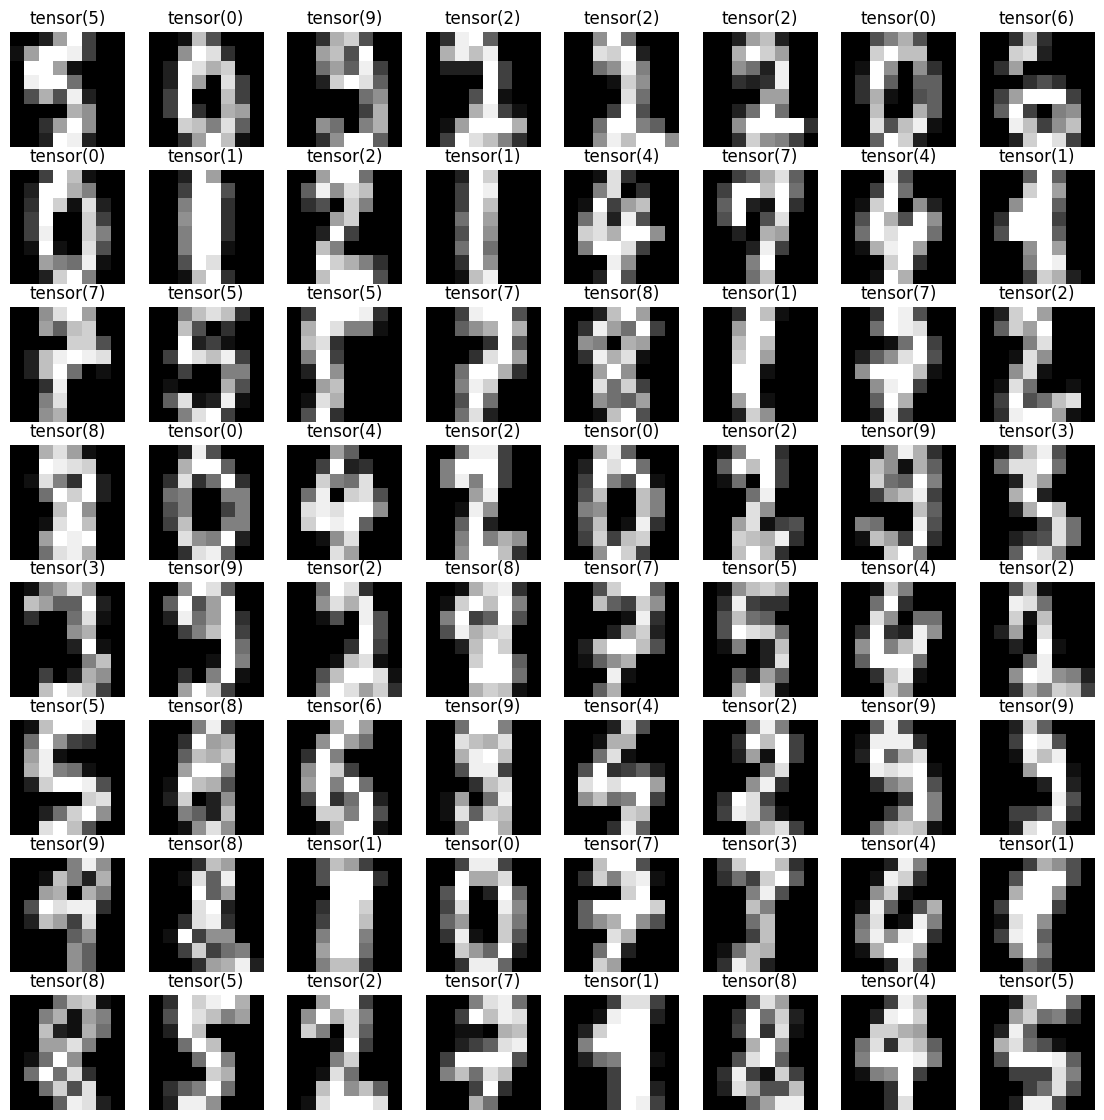

In [115]:
# iter: 반복문에 넣을 수 있는 iterable 객체로 만들어줌(list, tuple, dict 등과 같은 객체)
# next: iterable 객체에서 해당 요소를 하나씩 꺼냄
imgs, labels = next(iter(loader))
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(14, 14))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape((8, 8)), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')
# 23번의 업데이트 중 1번의 업데이트를 알려

In [116]:
model = nn.Sequential(
    nn.Linear(64, 10) # 8 x 8 사이즈의 이미지, 0~9의 클래스(확률)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

In [117]:
epochs = 50

for epoch in range(epochs + 1):
  sum_losses = 0
  sum_accs = 0

  for x_batch, y_batch in loader:
    y_pred = model(x_batch)
    loss = nn.CrossEntropyLoss()(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    sum_losses = sum_losses + loss

    y_prob = nn.Softmax(1)(y_pred)
    y_pred_index = torch.argmax(y_prob, axis=1) # y_prob가 최대가 되는 값;예측값
    acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100 # 정답률
    sum_accs = sum_accs + acc

  avg_loss = sum_losses / len(loader)
  avg_acc = sum_accs / len(loader)
  print(f'Epoch {epoch:4d}/{epochs} Loss: {avg_loss:.6f} Accuracy: {avg_acc:.2f}%')

Epoch    0/50 Loss: 1.641273 Accuracy: 58.48%
Epoch    1/50 Loss: 0.263871 Accuracy: 91.04%
Epoch    2/50 Loss: 0.154318 Accuracy: 95.24%
Epoch    3/50 Loss: 0.122760 Accuracy: 95.71%
Epoch    4/50 Loss: 0.104256 Accuracy: 96.64%
Epoch    5/50 Loss: 0.082549 Accuracy: 97.96%
Epoch    6/50 Loss: 0.070706 Accuracy: 98.34%
Epoch    7/50 Loss: 0.060386 Accuracy: 98.57%
Epoch    8/50 Loss: 0.057877 Accuracy: 98.64%
Epoch    9/50 Loss: 0.051199 Accuracy: 98.98%
Epoch   10/50 Loss: 0.047816 Accuracy: 98.76%
Epoch   11/50 Loss: 0.045528 Accuracy: 99.12%
Epoch   12/50 Loss: 0.036297 Accuracy: 99.52%
Epoch   13/50 Loss: 0.037318 Accuracy: 99.39%
Epoch   14/50 Loss: 0.033100 Accuracy: 99.46%
Epoch   15/50 Loss: 0.032075 Accuracy: 99.59%
Epoch   16/50 Loss: 0.038078 Accuracy: 99.16%
Epoch   17/50 Loss: 0.029211 Accuracy: 99.59%
Epoch   18/50 Loss: 0.031338 Accuracy: 99.46%
Epoch   19/50 Loss: 0.028703 Accuracy: 99.73%
Epoch   20/50 Loss: 0.032369 Accuracy: 99.46%
Epoch   21/50 Loss: 0.023173 Accur

In [118]:
y_test[10]

tensor(3)

In [119]:
y_pred = model(X_test)
y_pred[10]

tensor([ -2.9970,  -7.2364,   4.3926,   8.0314, -12.0842,  -2.5537,  -4.2749,
         -4.1356,   3.6971,   7.9336], grad_fn=<SelectBackward0>)

In [120]:
y_prob = nn.Softmax(1)(y_pred)
y_prob[10]

tensor([8.3407e-06, 1.2025e-07, 1.3504e-02, 5.1379e-01, 9.4346e-10, 1.2994e-05,
        2.3241e-06, 2.6715e-06, 6.7368e-03, 4.6595e-01],
       grad_fn=<SelectBackward0>)

In [121]:
for i in range(10):
  print(f'숫자 {i}일 확률: {y_prob[10][i]:.2f}')

숫자 0일 확률: 0.00
숫자 1일 확률: 0.00
숫자 2일 확률: 0.01
숫자 3일 확률: 0.51
숫자 4일 확률: 0.00
숫자 5일 확률: 0.00
숫자 6일 확률: 0.00
숫자 7일 확률: 0.00
숫자 8일 확률: 0.01
숫자 9일 확률: 0.47


In [122]:
y_pred_index = torch.argmax(y_prob, axis=1)
accuracy = (y_test == y_pred_index).float().sum() / len(y_test) * 100
print(f'테스트 정확도는 {accuracy: .2f}% 입니다.')

테스트 정확도는  95.56% 입니다.


# **3. 데이터 증강**

데이터 증강(Data Augmentation)은 학습 데이터를 인위적으로 변환하여 데이터셋의 다양성을 높이고 모델의 일반화 성능을 향상시키는 기법이다. **회전, 크기 조정, 반전, 블러링, 밝기 조정 등 다양한 변환을 적용하여 원본 데이터로부터 새로운 데이터를 생성하여 데이터 부족 문제를 완화하고 모델이 특정 패턴에 과적합되지 않도록 도와준다.** 특히, 이미지나 음성 데이터와 같이 특징이 직관적인 데이터에서 효과적으로 활용되며, 증강된 데이터는 모델이 예측 대상의 다양한 변형에 대해 강하게 학습할 수 있도록 돕는다.

In [123]:
from torchvision import transforms
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=2026)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([1437, 64]) torch.Size([1437])
torch.Size([360, 64]) torch.Size([360])


In [125]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

### ※ transforms.Compose
여러 데이터 변환(transform) 작업을 순차적으로 적용할 수 있도록 해준다. 이미지 데이터 전처리와 증강 과정에서 자주 사용되며, 각 변환을 하나의 리스트로 묶어 실행한다.
1. transforms.RandomRotation(10)
   - 기능: 이미지를 -10도에서 +10도 사이로 무작위 회전시킨다.
     - 10은 회전 범위를 나타낸다.
     - 각 호출 시, -10도 ~ +10도 범위에서 무작위로 각도를 선택하여 이미지를 회전한다.
2. transforms.RandomAffine(0, shear=5, scale=(0.9, 1.1))
   - 기능: 이미지를 비틀기(shear), 크기 조정(scale) 등의 변환을 수행한다.
     - 0: 회전(각도) 변환을 수행하지 않음을 의미합니다.
     - shear=5: 이미지를 최대 5도만큼 비스듬하게 비틀기(shear) 변환을 수행합니다.
       - 예: 정사각형이 평행사변형처럼 기울어질 수 있습니다.
     - scale=(0.9, 1.1):
       - 이미지를 0.9배(축소)에서 1.1배(확대) 범위 내에서 무작위 크기 조정을 수행합니다.
       - 각 호출 시, 무작위로 크기가 변경됩니다.

In [126]:
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear=5, scale=(0.9, 1.1)),
])

In [127]:
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        x = x.view(8, 8).unsqueeze(0)  # 8x8 이미지를 (1, 8, 8)로 변환
        x = self.transform(x)  # 증강 적용
        return x.flatten(), y  # 다시 Flatten

In [128]:
augmented_train_dataset = AugmentedDataset(train_dataset, transform)

In [129]:
len(augmented_train_dataset)

1437

In [130]:
augmented_train_dataset[0]

(tensor([ 0.,  0.,  5., 11., 16., 16.,  5.,  0.,  0.,  3., 15., 11., 10., 16.,
          4.,  0.,  0.,  0.,  4.,  0., 10., 14.,  0.,  0.,  0.,  0.,  7., 15.,
         16., 16., 12.,  0.,  0.,  0.,  9., 16., 14.,  4.,  1.,  0.,  0.,  0.,
          1., 14.,  7.,  0.,  0.,  0.,  0.,  0.,  4., 16.,  4.,  0.,  0.,  0.,
          0.,  0.,  8., 16.,  0.,  0.,  0.,  0.]),
 tensor(7))

In [131]:
train_loader = DataLoader(
    dataset=augmented_train_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False,
    drop_last=False
)

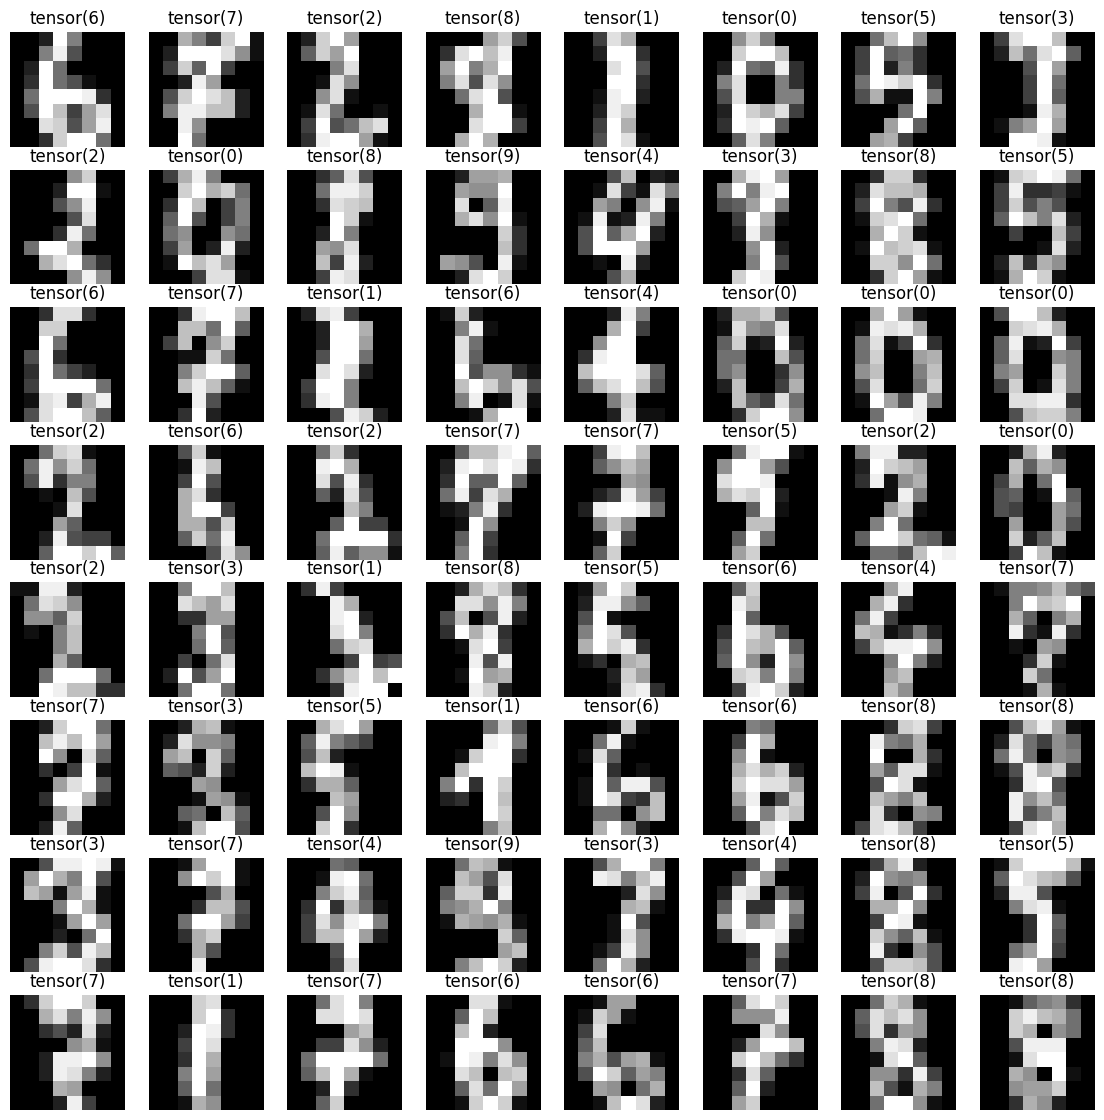

In [132]:
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(14, 14))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape((8, 8)), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')

In [133]:
for images, labels in train_loader:
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    break

Image batch shape: torch.Size([64, 64])
Label batch shape: torch.Size([64])


In [134]:
model = nn.Sequential(
    nn.Linear(64, 10)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

In [135]:
epochs = 50

for epoch in range(epochs + 1):
  sum_losses = 0
  sum_accs = 0

  for x_batch, y_batch in loader:
    y_pred = model(x_batch)
    loss = nn.CrossEntropyLoss()(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    sum_losses = sum_losses + loss

    y_prob = nn.Softmax(1)(y_pred)
    y_pred_index = torch.argmax(y_prob, axis=1) # y_prob가 최대가 되는 값;예측값
    acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100 # 정답률
    sum_accs = sum_accs + acc

  if epoch % 10 == 0:
    avg_loss = sum_losses / len(loader)
    avg_acc = sum_accs / len(loader)
    print(f'Epoch {epoch:4d}/{epochs} Loss: {avg_loss:.6f} Accuracy: {avg_acc:.2f}%')

Epoch    0/50 Loss: 1.649866 Accuracy: 59.67%
Epoch   10/50 Loss: 0.045435 Accuracy: 99.25%
Epoch   20/50 Loss: 0.027786 Accuracy: 99.39%
Epoch   30/50 Loss: 0.016105 Accuracy: 99.93%
Epoch   40/50 Loss: 0.011147 Accuracy: 99.73%
Epoch   50/50 Loss: 0.010348 Accuracy: 99.80%


tensor(5)


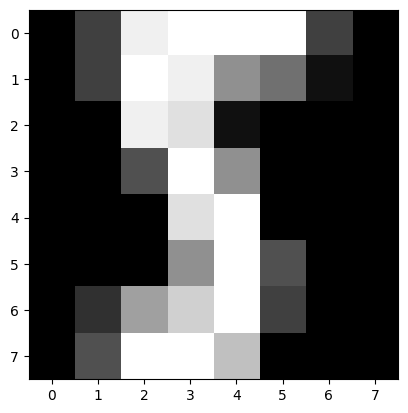

In [136]:
plt.imshow(X_test[11].reshape((8, 8)), cmap='gray')
print(y_test[11])

In [137]:
y_pred = model(X_test)
y_pred[11]

tensor([-10.3751,  -7.5921,  -2.5867,   6.1294, -18.6908,  15.4611,  -9.0636,
         -4.3956,  -1.5628,  -6.1189], grad_fn=<SelectBackward0>)

In [138]:
y_prob = nn.Softmax(1)(y_pred)
y_prob[11]

tensor([6.0178e-12, 9.7292e-11, 1.4518e-08, 8.8562e-05, 1.4722e-15, 9.9991e-01,
        2.2336e-11, 2.3785e-09, 4.0417e-08, 4.2450e-10],
       grad_fn=<SelectBackward0>)

In [139]:
for i in range(10):
  print(f'숫자 {i}일 확률: {y_prob[11][i]:.2f}')

숫자 0일 확률: 0.00
숫자 1일 확률: 0.00
숫자 2일 확률: 0.00
숫자 3일 확률: 0.00
숫자 4일 확률: 0.00
숫자 5일 확률: 1.00
숫자 6일 확률: 0.00
숫자 7일 확률: 0.00
숫자 8일 확률: 0.00
숫자 9일 확률: 0.00


In [140]:
y_pred_index = torch.argmax(y_prob, axis=1)
accuracy = (y_test == y_pred_index).float().sum() / len(y_test) * 100
print(f'테스트 정확도는 {accuracy: .2f}% 입니다.')

테스트 정확도는  95.83% 입니다.
